In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import scienceplots
plt.style.use('science')  # Requires matplotlib-style package

import seaborn as sns
from multiprocessing import Pool
from pprint import pprint
from IPython.display import clear_output

import os
from tqdm import tqdm
import json
os.chdir("../")
import src.utils as utils
import src.envs as envs
import src.models as mm

print(os.getcwd())
import main
from scipy.ndimage import convolve1d

from src.utils import setup_logger
logger = setup_logger(level=2)
logger(f"{logger}")

2025-11-18 02:14:32 | LoggerWrapper(name=MAIN,level=2, debugging=True, warning=True)


/home/doki/main_lab/minBandit


In [13]:
nb_rounds = 2000
nb_trials = 1
K = 200
env_type = "v0"
record_env = True

env = envs.make_new_env(K=K, env_type=env_type, nb_trials=nb_trials)
env.record = record_env
logger.info(f"%env: {env.__repr__()}")

# define model parameters
params = utils.load_model(idx=2)
params["K"] = K


# run
results2 = envs.trial_multiple_models(
                     models=[mm.Model(**params)],
                     environment=env,
                     nb_trials=nb_trials,
                     nb_rounds=nb_rounds,
                     nb_reps=1,
                     verbose=True)

logger(f"{results2['names'][0]}:\t{results2['score_list'][0][0]}")

results2.keys(), results2['reward_list'].shape

2025-11-11 23:18:25 | %env: KABv0(200, #sets=1)
2025-11-11 23:18:25 | Invalid parameters for Model, using Modelv2 instead
2025-11-11 23:18:25 | %names: ['Model']
2025-11-11 23:18:25 | %reps=1
2025-11-11 23:18:25 | %trials=1
2025-11-11 23:18:25 | %rounds=2000
2025-11-11 23:18:25 | Model: Model
2025-11-11 23:18:25 | K-armed bandit: KABv0
100%|███████████████████████████████████████████████████████████| 1/1 [00:42<00:00, 42.66s/it]
2025-11-11 23:19:07 | 
2025-11-11 23:19:07 | trial 0
2025-11-11 23:19:07 | >>> upper : 1.000
2025-11-11 23:19:07 | >>> chance: 0.514
2025-11-11 23:19:07 | >>> Model : 0.625
2025-11-11 23:19:07 | Model:	[0.625]


(dict_keys(['reward_list', 'chance_list', 'upper_bound_list', 'best_arm_list', 'arm_list', 'scores', 'score_list', 'names']),
 (1, 1, 1, 2000))

In [14]:
params

{'tau_u': 64,
 'tau_v': 111,
 'gain_v': 43.1,
 'offset_v': 3.8,
 'threshold_v': 0.37,
 'gain_u': 17.5,
 'offset_u': 2.8,
 'threshold_u': -0.31,
 'alpha': -2.0,
 'beta': 9.8,
 'mu': 4.0,
 'sigma': 1.7,
 'r': -0.07,
 'alpha_lr': 2.4,
 'beta_lr': 3.5,
 'mu_lr': 1.4,
 'sigma_lr': 1.8,
 'r_lr': 0.02,
 'w_max': 4.6,
 'dur_pre': 1065,
 'dur_post': 438,
 'Iext_intensity': 0.4,
 'K': 200}

### sensitivity analysis

In [13]:
def run(param: str, value: float,
        param2: str, value2: float,
        K: int, nb_rounds: int,  nb_trials: int,
        env_type: str, fixed_p: float=0.6, verbose: bool=True) -> dict:

    # define proababilities set
    probabilities_set = utils.make_probability_set(K=K,
                                                   nb_trials=nb_trials,
                                                   fixed_p=fixed_p,
                                                   normalize=False)
    # define the environment
    if env_type == "driftv0":
        env = envs.KABdriftv0(K=K,
                              probabilities_set=probabilities_set,
                              verbose=verbose,
                              tau=10)
    elif env_type == "driftv1":
        env = envs.KABdriftv1(K=K,
                              verbose=verbose,
                              tau=100,
                              normalize=True,
                              fixed_p=0.9)
    elif env_type == "sinv0":
        frequencies = np.linspace(0.1, 0.4, K)
        env = envs.KABsinv0(K=K,
                            frequencies=frequencies,
                            normalize=True,
                            verbose=verbose)
    else:
        env = envs.KABv0(K=K,
                         probabilities_set=probabilities_set,
                         verbose=verbose)

    # define the model
    params = utils.load_model(idx=5)
    params["K"] = K
    
    assert param in tuple(params.keys()), f"{param} not recognized as a model parameters"
    params[param] = value
    assert param2 in tuple(params.keys()), f"{param2} not recognized as a model parameters"
    params[param2] = value2

    # run
    results = envs.trial(model=mm.Model(**params),
                         environment=env,
                         nb_trials=nb_trials,
                         nb_rounds=nb_rounds,
                         verbose=verbose,
                         disable=True)

    return results

def redact_score(results):
    return (results['score'] - results['chance']) / (results['upper_bound'] - results['chance'])

logger()

2025-11-18 02:27:01 | 


#### duration

In [41]:
np.random.seed(1)

# ---
K = 10
num_param = 6

nb_rounds = 600
nb_trials = 1
nb_reps = 7
env_type = "default"
fixed_p = 0.9

# ---
param = "dur_post"
param_name = "dur$_{{post}}$"
values = np.around(np.linspace(10, 500, num_param)).astype(int)
values = np.flip(values, axis=0)

param2 = "dur_pre"
param2_name = "dur$_{{pre}}$"
values2 = np.around(np.linspace(10, 500, num_param)).astype(int)
table = np.zeros((num_param, num_param))

# ---
pbar = tqdm(range(num_param))
pbar2 = tqdm(range(num_param))
for i in pbar:
    pbar.set_description(f"dur_pre: {values[i]}")
    for j in pbar2:
        pbar2.set_description(f"dur_post: {values[i]}")
        for _ in range(nb_reps):
            results = run(param=param, value=values[i],
                          param2=param2, value2=values2[j],
                          K=K, nb_rounds=nb_rounds,
                          nb_trials=nb_trials, env_type=env_type, fixed_p=fixed_p,
                          verbose=False)
            table[i, j] += redact_score(results)

        table[i, j] /= nb_reps

logger()

dur_pre: 10: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [11:55<00:00, 119.21s/it]
2025-11-18 03:32:49 | 


**plot**

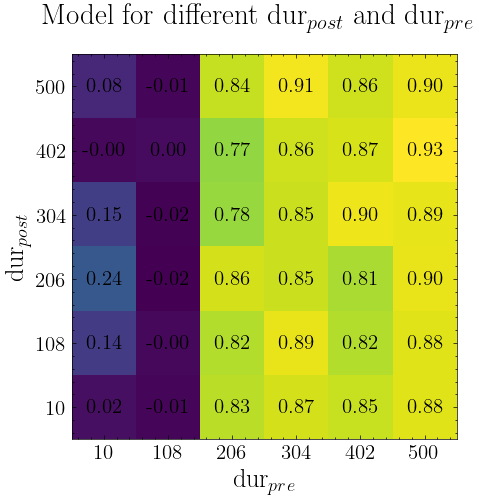

In [42]:
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(table, cmap="viridis")

ax.set_xticks(range(num_param))
ax.set_xticklabels(values2, fontsize=15)
ax.set_xlabel(f"{param2_name}", fontsize=19)

ax.set_yticks(range(num_param))
ax.set_yticklabels(values, fontsize=15)
ax.set_ylabel(f"{param_name}", fontsize=19)

for i in range(len(table)):
    for j in range(len(table[i])):
        _ = ax.text(i, j, f"{table[j, i]:.2f}", ha="center", va="center", color="black",
                    fontsize=15)

fig.suptitle(f"Model for different {param_name} and {param2_name}", fontsize=21)

plt.show()

